<a href="https://colab.research.google.com/github/faezesarlakifar/AllerTrans/blob/main/additional-experiments/recombinant-proteins-test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @markdown import necessaries
from google.colab import drive
from tqdm.notebook import tqdm
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score

In [2]:
# @markdown mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/allergen-detection/embeddings/'

In [4]:
# @markdown load dataset

esm_path = path+'esm-embeddings-with-id/'
esm_recombinant = pd.read_csv(esm_path+'df_recombinant.csv')

protbert_path = path+'protBERT-embeddings-with-id/'
protT5_recombinant = pd.read_csv(protbert_path+'df_recombinant.csv')

In [5]:
esm_recombinant.head()

,0,1,2,3,4,5,6,7,8,9,...,1272,1273,1274,1275,1276,1277,1278,1279,Label,id
0,0.052800,-0.030682,-0.004370,-0.007540,-0.070134,-0.110161,0.044311,-0.082190,-0.064010,0.050366,...,-0.055819,-0.003537,-0.043055,-0.007318,0.123666,-0.154588,-0.037514,0.036862,1.0,sp|Q4JK71|CHL18_DERPT
1,-0.003356,-0.064581,0.059352,0.072772,0.000428,-0.074968,0.093049,-0.178745,-0.085395,0.073691,...,0.021816,0.034623,-0.060200,-0.051319,0.165005,-0.158005,0.006783,0.036593,1.0,sp|A1KXI1|BLOT3_BLOTA
2,-0.129869,-0.152867,-0.136635,0.069603,-0.102745,-0.057927,0.108667,-0.143834,-0.103473,0.205308,...,0.043120,0.071082,-0.071695,-0.032927,0.055249,-0.227378,-0.064186,0.050385,1.0,sp|A0A7G2A2Z3|NLTP_MACIN
3,0.015861,-0.042827,-0.054280,0.080565,-0.050009,-0.122558,0.101025,-0.069118,-0.032784,0.064489,...,-0.068779,-0.003743,-0.008235,-0.024095,0.076168,-0.085637,-0.103603,0.024716,1.0,sp|Q8GZP6|ANAO2_ANAOC
4,0.012299,-0.039640,-0.055187,0.100739,-0.069712,-0.083086,0.104195,-0.058096,-0.066824,0.083526,...,-0.094417,0.027353,-0.018480,-0.036707,0.040085,-0.106445,-0.064227,0.048901,1.0,sp|B5KVH4|11S1_CARIL


In [6]:
protT5_recombinant.head()

,0,1,2,3,4,5,6,7,8,9,...,1016,1017,1018,1019,1020,1021,1022,1023,Label,id
0,0.027064,0.028032,0.058204,0.008597,-0.009560,0.013149,-0.082644,-0.094474,-0.011705,-0.038316,...,-0.004931,-0.059760,0.027508,-0.003489,-0.018631,0.032065,-0.008539,0.024221,1,sp|Q5GMY3|GMCH_MALSM
1,0.012791,-0.103621,0.030675,0.032476,0.003075,-0.013211,-0.050219,-0.049055,0.038538,-0.001868,...,-0.037868,-0.037373,0.018352,0.034478,0.029086,-0.062517,0.051323,0.070533,1,sp|C7E9V9|SCH34_STACH
2,0.011361,0.003533,0.031491,-0.010823,-0.007967,0.039780,-0.008649,-0.081571,0.010433,-0.078721,...,-0.014223,-0.025526,0.044710,0.008849,-0.005146,0.038961,0.054947,0.021287,1,sp|V5LU01|CEP01_AMBAR
3,-0.016785,0.081792,0.033216,-0.001997,0.003866,-0.014062,0.066917,-0.030769,-0.005011,-0.041625,...,-0.026331,-0.001025,0.035879,-0.026063,-0.004893,0.060487,0.012191,-0.028521,1,sp|P81295|PRR3_JUNAS
4,0.023460,-0.047014,0.034690,-0.069520,0.020334,0.020611,-0.002960,-0.141983,-0.001380,-0.018745,...,-0.018276,-0.014078,-0.006972,-0.112850,-0.017422,-0.069397,0.078808,0.060572,1,sp|Q66RP5|FABP_TYRPU


In [7]:
esm_recombinant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Columns: 1282 entries, 0 to id
dtypes: float64(1281), object(1)
memory usage: 841.4+ KB


In [8]:
protT5_recombinant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Columns: 1026 entries, 0 to id
dtypes: float64(1024), int64(1), object(1)
memory usage: 673.4+ KB


In [9]:
# @title Concatenate DataFrames
test = pd.merge(
    left=esm_recombinant,
    right=protT5_recombinant,
    on='id'
)
test.head()

,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,8_x,9_x,...,1015_y,1016_y,1017_y,1018_y,1019_y,1020_y,1021_y,1022_y,1023_y,Label_y
0,0.052800,-0.030682,-0.004370,-0.007540,-0.070134,-0.110161,0.044311,-0.082190,-0.064010,0.050366,...,-0.020019,-0.001406,-0.033531,0.049785,0.046556,0.022389,0.023743,0.095386,0.072203,1
1,-0.003356,-0.064581,0.059352,0.072772,0.000428,-0.074968,0.093049,-0.178745,-0.085395,0.073691,...,-0.022670,-0.042028,-0.058717,0.005290,0.025396,-0.005006,0.019539,0.021814,0.006587,1
2,-0.129869,-0.152867,-0.136635,0.069603,-0.102745,-0.057927,0.108667,-0.143834,-0.103473,0.205308,...,-0.069021,0.011675,-0.030831,-0.004466,0.001873,-0.070552,0.035383,-0.043133,-0.024689,1
3,0.015861,-0.042827,-0.054280,0.080565,-0.050009,-0.122558,0.101025,-0.069118,-0.032784,0.064489,...,-0.012946,0.058624,-0.099265,-0.001999,-0.034461,-0.028585,0.083939,0.154087,0.040171,1
4,0.012299,-0.039640,-0.055187,0.100739,-0.069712,-0.083086,0.104195,-0.058096,-0.066824,0.083526,...,-0.001274,0.055787,-0.093134,-0.031661,-0.024589,-0.024300,0.084759,0.178273,0.042685,1


In [10]:
test['Label'] = test['Label_x']
test = test.drop(columns=['Label_x', 'Label_y'])
test.head()

,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,8_x,9_x,...,1015_y,1016_y,1017_y,1018_y,1019_y,1020_y,1021_y,1022_y,1023_y,Label
0,0.052800,-0.030682,-0.004370,-0.007540,-0.070134,-0.110161,0.044311,-0.082190,-0.064010,0.050366,...,-0.020019,-0.001406,-0.033531,0.049785,0.046556,0.022389,0.023743,0.095386,0.072203,1.0
1,-0.003356,-0.064581,0.059352,0.072772,0.000428,-0.074968,0.093049,-0.178745,-0.085395,0.073691,...,-0.022670,-0.042028,-0.058717,0.005290,0.025396,-0.005006,0.019539,0.021814,0.006587,1.0
2,-0.129869,-0.152867,-0.136635,0.069603,-0.102745,-0.057927,0.108667,-0.143834,-0.103473,0.205308,...,-0.069021,0.011675,-0.030831,-0.004466,0.001873,-0.070552,0.035383,-0.043133,-0.024689,1.0
3,0.015861,-0.042827,-0.054280,0.080565,-0.050009,-0.122558,0.101025,-0.069118,-0.032784,0.064489,...,-0.012946,0.058624,-0.099265,-0.001999,-0.034461,-0.028585,0.083939,0.154087,0.040171,1.0
4,0.012299,-0.039640,-0.055187,0.100739,-0.069712,-0.083086,0.104195,-0.058096,-0.066824,0.083526,...,-0.001274,0.055787,-0.093134,-0.031661,-0.024589,-0.024300,0.084759,0.178273,0.042685,1.0


In [11]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Columns: 2306 entries, 0_x to Label
dtypes: float64(2305), object(1)
memory usage: 1.5+ MB


In [12]:
df_test = test

# Preprocess and Prepare Dataset

In [13]:
df_test = df_test.drop('id', axis=1)

In [14]:
# Convert Label to integer
df_test['Label'] = df_test['Label'].astype(int)

X_test = df_test.drop('Label', axis=1)
y_test = df_test['Label']

In [15]:
# Create new feature names
feature_names = ['feat_'+str(i) for i in range(X_test.shape[1])]

# Rename columns
X_test.columns = feature_names

In [16]:
scaler = MinMaxScaler()
X_test_scaled = scaler.fit_transform(X_test)

# Convert to PyTorch tensors
X_test_scaled = torch.from_numpy(X_test_scaled).float()
X_test = X_test_scaled


In [17]:
# Convert to numpy arrays
y_test = np.array(y_test)

# Create Tensors from Labels
y_test = torch.from_numpy(y_test).long()

In [18]:
X_test.shape

torch.Size([84, 2304])

In [19]:
X_test_cat = X_test
y_test_cat = y_test

# ProtT5 + DNN

## Define Model

In [20]:
# Model class
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.fc4 = nn.Linear(hidden_size3, num_classes)


    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)
        return out

## Load Trained Model's Weights

In [21]:
PATH = 'model17-protT5.pt'

In [22]:
model_protT5 = NeuralNet(1024, 200, 100, 50, 2)
model_protT5.load_state_dict(torch.load(PATH))
model_protT5.eval()

NeuralNet(
  (fc1): Linear(in_features=1024, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=50, bias=True)
  (fc4): Linear(in_features=50, out_features=2, bias=True)
)

In [23]:
model_protbert = model_protT5

# Prot-ESM + DNN

In [24]:
X_test = X_test_cat
y_test = y_test_cat

In [25]:
PATH = 'model-esm-protT5-5.pt'

In [26]:
model_cat = NeuralNet(2304, 200, 100, 100, 2)
model_cat.load_state_dict(torch.load(PATH))
model_cat.eval()

NeuralNet(
  (fc1): Linear(in_features=2304, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=100, bias=True)
  (fc4): Linear(in_features=100, out_features=2, bias=True)
)

In [ ]:
# Test predictions
with torch.no_grad():
    outputs = model_cat(X_test_cat)

# Get predictions
_, predicted = torch.max(outputs.data, 1)

# Convert predicted and y_test to NumPy arrays
predicted_np = predicted.cpu().numpy()
y_test_np = y_test.cpu().numpy()

# Calculate accuracy
accuracy = accuracy_score(y_test_np, predicted_np)

# Calculate precision, recall and F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, predicted_np, average='weighted')

# Calculate metrics
_, recall_, _, _ = precision_recall_fscore_support(y_test_np, predicted_np, labels=[0,1])

# Recall for negative class (index 0)
neg_recall = recall_[0]

# Recall for positive class (index 1)
pos_recall = recall_[1]

print("Negative class recall:", neg_recall)
print("Positive class recall:", pos_recall)
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Get probability distribution
probs = F.softmax(model_cat(X_test_cat), dim=1)

# Take positive class probability as scores
y_scores = probs[:,1]

roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
print("ROCAUC:", roc_auc )

mcc = matthews_corrcoef(y_test, predicted)

print("MCC:", mcc)

Negative class recall: 0.7142857142857143
Positive class recall: 0.9523809523809523
Accuracy: 0.8333333333333334
Precision: 0.8533653846153846
Recall: 0.8333333333333334
F1 Score: 0.8309373202990226
ROCAUC: 0.9319727891156462
MCC: 0.6864064729836441


# Ensemble models (ProtT5 & Prot-ESM)

In [29]:
# @markdown Load Test Datasets
path = '/content/drive/MyDrive/allergen-detection/embeddings/'

protbert_path = path+'protBERT-embeddings-with-id/'
protbert_test = pd.read_csv(protbert_path+'df_recombinant.csv')


In [30]:
concat_test = test

In [31]:
test.head()

,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,8_x,9_x,...,1015_y,1016_y,1017_y,1018_y,1019_y,1020_y,1021_y,1022_y,1023_y,Label
0,0.052800,-0.030682,-0.004370,-0.007540,-0.070134,-0.110161,0.044311,-0.082190,-0.064010,0.050366,...,-0.020019,-0.001406,-0.033531,0.049785,0.046556,0.022389,0.023743,0.095386,0.072203,1.0
1,-0.003356,-0.064581,0.059352,0.072772,0.000428,-0.074968,0.093049,-0.178745,-0.085395,0.073691,...,-0.022670,-0.042028,-0.058717,0.005290,0.025396,-0.005006,0.019539,0.021814,0.006587,1.0
2,-0.129869,-0.152867,-0.136635,0.069603,-0.102745,-0.057927,0.108667,-0.143834,-0.103473,0.205308,...,-0.069021,0.011675,-0.030831,-0.004466,0.001873,-0.070552,0.035383,-0.043133,-0.024689,1.0
3,0.015861,-0.042827,-0.054280,0.080565,-0.050009,-0.122558,0.101025,-0.069118,-0.032784,0.064489,...,-0.012946,0.058624,-0.099265,-0.001999,-0.034461,-0.028585,0.083939,0.154087,0.040171,1.0
4,0.012299,-0.039640,-0.055187,0.100739,-0.069712,-0.083086,0.104195,-0.058096,-0.066824,0.083526,...,-0.001274,0.055787,-0.093134,-0.031661,-0.024589,-0.024300,0.084759,0.178273,0.042685,1.0


In [32]:
protbert_test.head()

,0,1,2,3,4,5,6,7,8,9,...,1016,1017,1018,1019,1020,1021,1022,1023,Label,id
0,0.027064,0.028032,0.058204,0.008597,-0.009560,0.013149,-0.082644,-0.094474,-0.011705,-0.038316,...,-0.004931,-0.059760,0.027508,-0.003489,-0.018631,0.032065,-0.008539,0.024221,1,sp|Q5GMY3|GMCH_MALSM
1,0.012791,-0.103621,0.030675,0.032476,0.003075,-0.013211,-0.050219,-0.049055,0.038538,-0.001868,...,-0.037868,-0.037373,0.018352,0.034478,0.029086,-0.062517,0.051323,0.070533,1,sp|C7E9V9|SCH34_STACH
2,0.011361,0.003533,0.031491,-0.010823,-0.007967,0.039780,-0.008649,-0.081571,0.010433,-0.078721,...,-0.014223,-0.025526,0.044710,0.008849,-0.005146,0.038961,0.054947,0.021287,1,sp|V5LU01|CEP01_AMBAR
3,-0.016785,0.081792,0.033216,-0.001997,0.003866,-0.014062,0.066917,-0.030769,-0.005011,-0.041625,...,-0.026331,-0.001025,0.035879,-0.026063,-0.004893,0.060487,0.012191,-0.028521,1,sp|P81295|PRR3_JUNAS
4,0.023460,-0.047014,0.034690,-0.069520,0.020334,0.020611,-0.002960,-0.141983,-0.001380,-0.018745,...,-0.018276,-0.014078,-0.006972,-0.112850,-0.017422,-0.069397,0.078808,0.060572,1,sp|Q66RP5|FABP_TYRPU


In [33]:
# @title Preprocess and prepare dataset

protbert_test = protbert_test.set_index('id').reindex(test.id).reset_index()

protbert_test = protbert_test.drop('id', axis=1)

# Convert Label to integer
protbert_test['Label'] = protbert_test['Label'].astype(int)

X_test_protbert = protbert_test.drop('Label', axis=1)

# Create new feature names
feature_names = ['feat_'+str(i) for i in range(X_test_protbert.shape[1])]

# Rename columns
X_test_protbert.columns = feature_names

scaler = MinMaxScaler()
X_test_protbert_scaled = scaler.fit_transform(X_test_protbert)

# Convert to PyTorch tensors
X_test_protbert_scaled = torch.from_numpy(X_test_protbert_scaled).float()
X_test_protbert = X_test_protbert_scaled

In [57]:
# @title Ensemble Models
# Set the weights for each model
weight1 = 0.30
weight2 = 0.60

# Put both models in evaluation mode
model_cat.eval()
model_protbert.eval()

# Iterate over the test dataset and compute the ensemble predictions
with torch.no_grad():
        outputs1 = model_cat(X_test_cat)
        outputs2 = model_protbert(X_test_protbert)
        ensemble_outputs = weight1 * outputs1 + weight2 * outputs2

In [58]:
_, predicted = torch.max(ensemble_outputs.data, 1)

In [59]:
ensemble_preds = predicted

In [37]:
# Convert predicted and y_test to NumPy arrays
ensemble_preds_np = ensemble_preds.cpu().numpy()
y_test_np = y_test.cpu().numpy()

# Calculate accuracy
accuracy = accuracy_score(y_test_np, ensemble_preds_np)

# Calculate precision, recall and F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, ensemble_preds_np, average='weighted')

# Calculate metrics
_, recall_, _, _ = precision_recall_fscore_support(y_test_np, ensemble_preds_np, labels=[0,1])

# Recall for negative class (index 0)
neg_recall = recall_[0]

# Recall for positive class (index 1)
pos_recall = recall_[1]

print("Negative class recall:", neg_recall)
print("Positive class recall:", pos_recall)
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Get probability distribution
probs = F.softmax(ensemble_outputs, dim=1)

# Take positive class probability as scores
y_scores = probs[:,1]

roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
print("ROCAUC:", roc_auc )

mcc = matthews_corrcoef(y_test, predicted)

print("MCC:", mcc)

Negative class recall: 0.8095238095238095
Positive class recall: 0.9523809523809523
Accuracy: 0.8809523809523809
Precision: 0.8888888888888887
Recall: 0.8809523809523809
F1 Score: 0.8803418803418802
ROCAUC: 0.943877551020408
MCC: 0.769800358919501


# Plots

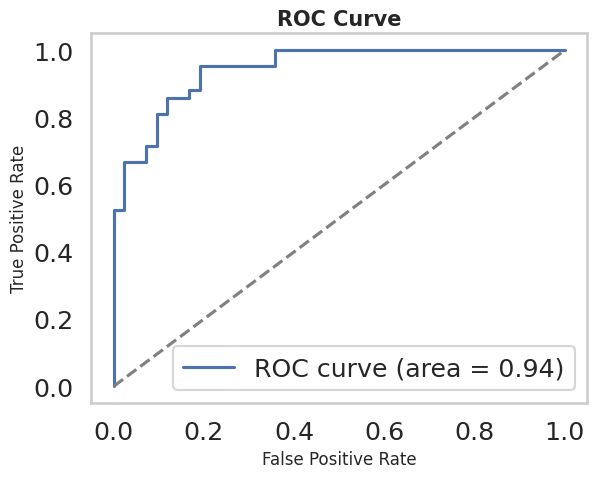

In [103]:
# @title AUC-ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_np, y_scores.detach().numpy())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc="lower right")
plt.grid()
plt.show()


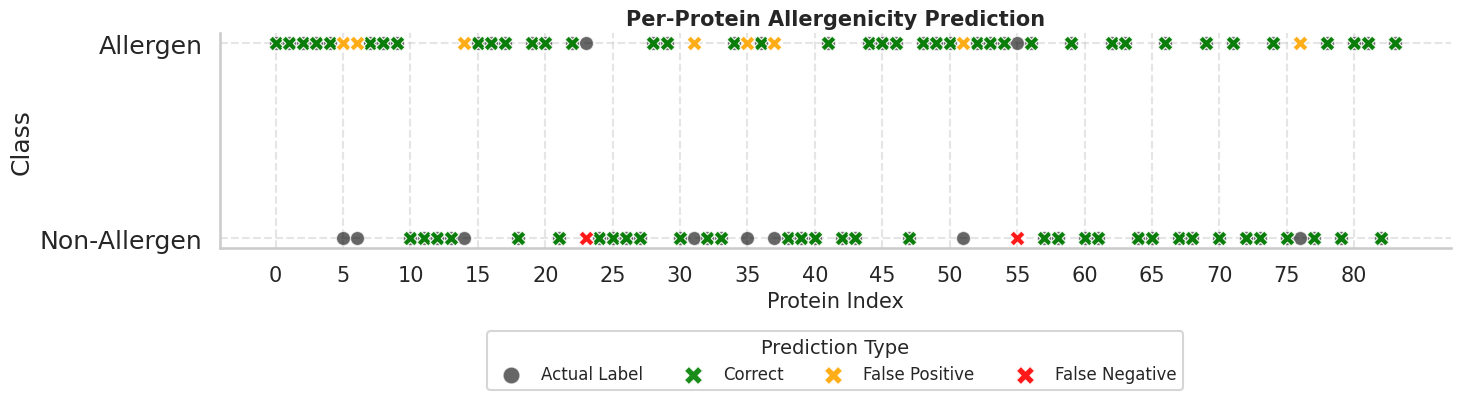

In [98]:
# @title Per-Protein Allergenicity Prediction Plot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame
df = pd.DataFrame({
    "Protein Index": range(len(y_test_np)),
    "Actual Label Num": y_test_np,
    "Predicted Label Num": ensemble_preds_np
})

# Map to class names
label_map = {0: "Non-Allergen", 1: "Allergen"}
df["Actual Label"] = df["Actual Label Num"].map(label_map)
df["Predicted Label"] = df["Predicted Label Num"].map(label_map)

# Classify prediction type
def classify(row):
    if row["Actual Label Num"] == row["Predicted Label Num"]:
        return "Correct"
    elif row["Actual Label Num"] == 0 and row["Predicted Label Num"] == 1:
        return "False Positive"
    elif row["Actual Label Num"] == 1 and row["Predicted Label Num"] == 0:
        return "False Negative"
df["Result"] = df.apply(classify, axis=1)

# Assign colors
color_map = {
    "Correct": "green",
    "False Positive": "orange",
    "False Negative": "red"
}

# Plot
plt.figure(figsize=(15, 5))

# Actual labels (circles)
sns.scatterplot(
    data=df,
    x="Protein Index",
    y="Actual Label",
    color='black',
    label='Actual Label',
    marker='o',
    s=100,
    alpha=0.6
)

# Predicted labels (crosses), colored by correctness
for result_type, color in color_map.items():
    subset = df[df["Result"] == result_type]
    sns.scatterplot(
        data=subset,
        x="Protein Index",
        y="Predicted Label",
        color=color,
        label=result_type,
        marker='X',
        s=120,
        alpha=0.9
    )

# Final touches
plt.title("Per-Protein Allergenicity Prediction", fontsize=15, fontweight='bold')
plt.xlabel("Protein Index", fontsize=15)
plt.ylabel("Class", fontsize=18)
plt.xticks(range(0, 84, 5), fontsize=15)
plt.legend(
    title="Prediction Type",
    title_fontsize=14,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=4,
    fontsize=12,
    markerscale=1.2
)

plt.grid(True, linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()
